In [1]:
import numpy as np
import pandas as pd


In [2]:
#set initial conditions and true values
c10 = 1
c20 = 0
#rabi frequency
om = 2.0

In [5]:
time = np.linspace(0, 10, 200)

In [21]:
real_osc = [(np.sin(om*t/2))**2 for t in time]

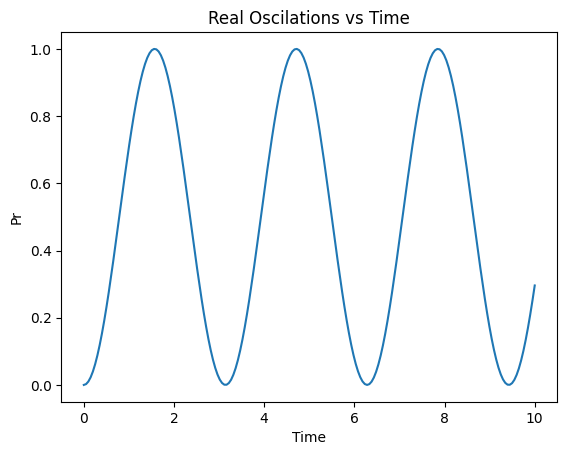

In [44]:
import matplotlib.pyplot as plt

plt.plot(time, real_osc)
plt.title("Real Oscilations vs Time")
plt.xlabel("Time")
plt.ylabel("Pr") #Should check what this actually is
plt.show()

In [28]:
#simulated noise
measured_data = [x + np.random.normal(loc=0, scale=.1) for x in real_osc]

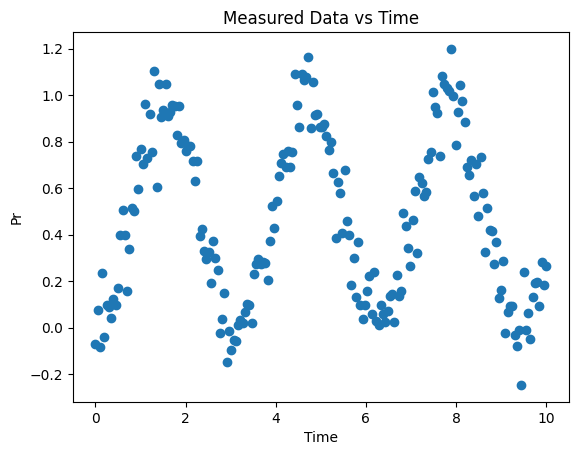

In [45]:
plt.plot(time, measured_data, "o")
plt.title("Measured Data vs Time")
plt.xlabel("Time")
plt.ylabel("Pr") #Should check what this actually is
plt.show()

In [38]:
#fit curve to noisy data

#need rabi function:
def rabi (t, o):
    return (np.sin(o*t/2))**2

In [39]:
from scipy.optimize import curve_fit

In [42]:
fit = curve_fit(rabi, time, measured_data, p0=[1.6])

In [43]:
#view predicted omega and variance
print(fit)

(array([2.0007427]), array([[1.37643431e-05]]))


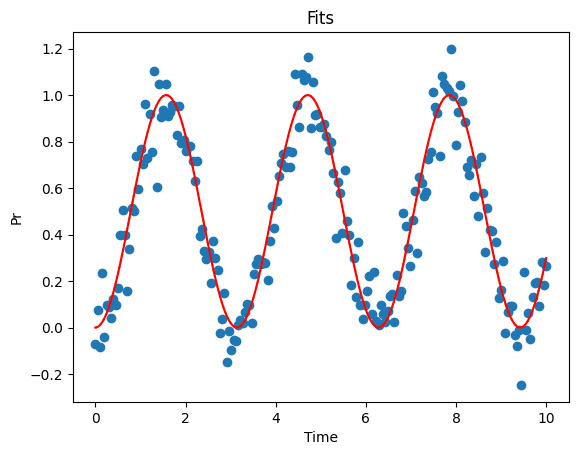

In [52]:
est_curve = [(np.sin(fit[0][0]*t/2))**2 for t in time]

plt.plot(time, measured_data, "o")
plt.plot(time, real_osc, linestyle='dotted')
plt.plot(time, est_curve, color = 'red')
plt.title("Fits")
plt.xlabel("Time")
plt.ylabel("Pr") 
plt.show()

In [53]:
#compare to sklearn fit
from sklearn.linear_model import LinearRegression

#write rwa in notes and derive oscilation equation
#Fourier series for linear combination
#reminder: fourier series => compose periodic function by linear combination of sin(x) + cos(x) + sin(2x) + cos(2x) + ......

In [63]:
s_list = []
#arbitrary chosen length of fourier series
for i in range(1, 5):
    s_list.append(np.sin(i * time))
    s_list.append(np.cos(i * time))

series = np.column_stack(s_list)

In [64]:
reg_model = LinearRegression()
reg_model.fit(series, measured_data)
pred_reg = reg_model.predict(series)

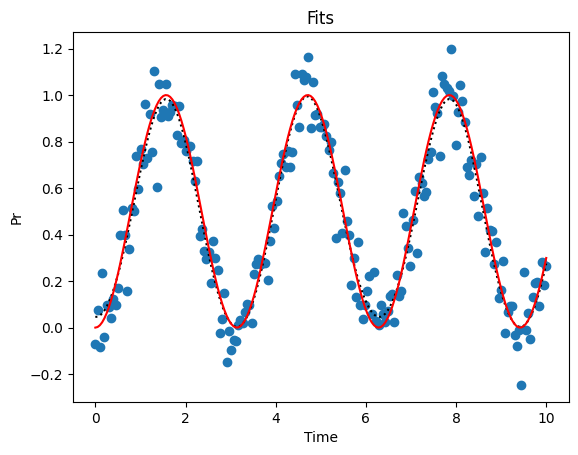

In [66]:
plt.plot(time, measured_data, "o")
plt.plot(time, pred_reg, linestyle='dotted', color='black')
plt.plot(time, est_curve, color = 'red')
plt.title("Fits")
plt.xlabel("Time")
plt.ylabel("Pr") 
plt.show()